**Yilin Pan, Daniel Lyu**

Spring 2026

CS 443: Bio-inspired Machine Learning

Project 2: Predictive Coding

#### Week 2: Predictive coding: classification and image generation

With the Dense PCN built, let's analyze its classification accuracy on MNIST and CIFAR-10 and explore its generative image capabilities. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.show()
plt.rcParams.update({'font.size': 18})

np.set_printoptions(suppress=True, precision=3)

%load_ext autoreload
%autoreload 2

## Task 3: Dense PCN and MNIST

Now you are ready to train your Dense PCN on MNIST!

In addition to optimizing the classification accuracy, you will:
1. visualize the "ideal" digit that each output neuron of a trained net "expects to see".
2. leverage this generative capability of PCNs to "fill in" blanked out parts of test samples.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
project_path = '/content/drive/MyDrive/ColabNotebooks/project2'
os.chdir(project_path)

In [4]:
from image_datasets import get_dataset, train_val_split
from dense_pcn import DensePCN

### 3a. Train and evaluate classification accuracy on MNIST

In the cell below, train a Dense PCN with 1 hidden layer on *centered* preprocessed MNIST samples with the default train/val/test split.

Your goal is to play with the following hyperparameters to obtain **≥75% accuracy on the test set**:
- number of epochs
- batch size
- number of units

Fix your learning rate to `1e-4` and use the default number of train/test feedback iterations.

Be sure to print out your test accuracy.


**Notes:**
- If your training is working properly, you should see your training loss consistently decline.
- You should not need to train for many epochs to hit the accuracy target. 
- I suggest setting a random seed so that similar to the test code your results do not fluctuate based on differences in initial random weights between runs.

In [5]:
import time

tf.random.set_seed(42)
np.random.seed(42)

x_train_full, y_train_full, x_test, y_test = get_dataset('mnist', norm_method='center')
x_train, y_train, x_val, y_val = train_val_split(x_train_full, y_train_full)

M = x_train.shape[1]
C = 10
hidden_units = (512,)
num_epochs = 5
batch_size = 128
lr = 1e-4

net = DensePCN(input_feats_shape=(M,), C=C, hidden_units=hidden_units, wt_scale=1e-2, gamma_lr=0.1)
net.compile(loss='predictive', lr=lr, print_summary=True)

x_train shape: (60000, 784), dtype: <dtype: 'float32'>
y_train shape: (60000,), dtype: <dtype: 'int32'>
x_test shape: (10000, 784), dtype: <dtype: 'float32'>
y_test shape: (10000,), dtype: <dtype: 'int32'>
---------------------------------------------------------------------------
OutputLayer (10 units). Output shape: None
PredLayer_0 (512 units). Output shape: None
InputLayer (784 units). Output shape: None
---------------------------------------------------------------------------


In [6]:
N = len(x_train)
num_batches = N // batch_size
rng = np.random.default_rng(42)
train_loss_hist = []

for epoch in range(num_epochs):
    start_time = time.time()
    epoch_loss = 0.0

    for b in range(num_batches):
        indices = rng.integers(low=0, high=N, size=batch_size)
        x_batch = tf.gather(x_train, indices)
        y_batch = tf.gather(y_train, indices)

        net.set_layer_training_mode(True)
        # iteratively update states with labels clamped at the output
        net.update_states(net.train_num_steps, x_batch, y_batch)

        # Compute predictive loss and update weights via backprop
        with tf.GradientTape() as tape:
            loss = net.loss()
        net.update_params(tape, loss)
        epoch_loss += float(loss)

    epoch_loss /= num_batches
    train_loss_hist.append(epoch_loss)

    val_acc, val_loss = net.evaluate(x_val, y_val)
    elapsed = time.time() - start_time
    print(f'Epoch {epoch+1}/{num_epochs} | {elapsed:.1f}s | train_loss: {epoch_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

# Evaluate on test set
test_acc, test_loss = net.evaluate(x_test, y_test)
print(f'\nTest accuracy: {test_acc*100:.2f}%  |  Test loss: {test_loss:.4f}')

Epoch 1/5 | 36.1s | train_loss: 17.4105 | val_loss: 17.9337 | val_acc: 0.7900
Epoch 2/5 | 35.0s | train_loss: 8.6766 | val_loss: 12.5800 | val_acc: 0.8179
Epoch 3/5 | 35.0s | train_loss: 6.1148 | val_loss: 12.9839 | val_acc: 0.8330
Epoch 4/5 | 34.9s | train_loss: 4.8379 | val_loss: 13.4785 | val_acc: 0.8345
Epoch 5/5 | 34.9s | train_loss: 4.0525 | val_loss: 14.2829 | val_acc: 0.8322

Test accuracy: 80.83%  |  Test loss: 14.3062


### 3b. Hyperparameter tuning: test steps

With the same hyperparameters that you used in the previous subtask, run inference on your Dense PCN to compute the test accuracy with the following number of test steps: `1, 10, 20, 30, ..., 100`.

Make a plot showing the MNIST test accuracy in each case.

test_steps=  1  |  test_acc=0.7295
test_steps= 10  |  test_acc=0.8083
test_steps= 20  |  test_acc=0.7778
test_steps= 30  |  test_acc=0.7673
test_steps= 40  |  test_acc=0.7671
test_steps= 50  |  test_acc=0.7706
test_steps= 60  |  test_acc=0.7758
test_steps= 70  |  test_acc=0.7812
test_steps= 80  |  test_acc=0.7858
test_steps= 90  |  test_acc=0.7893
test_steps=100  |  test_acc=0.7919


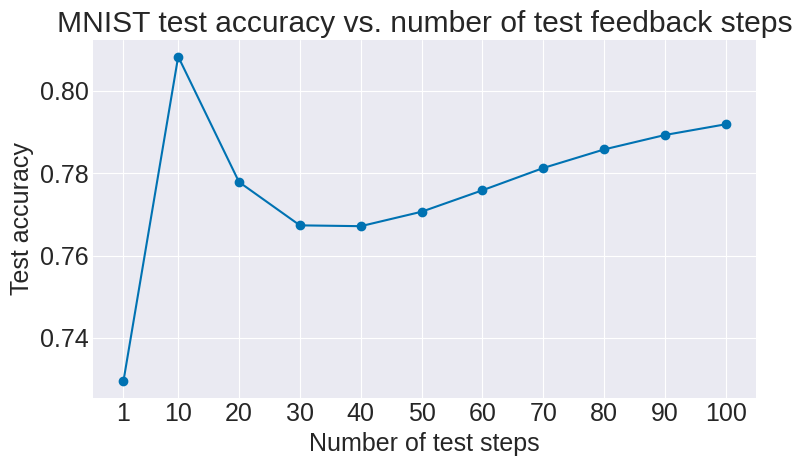

In [7]:
test_steps_list = [1] + list(range(10, 101, 10))
test_accs = []

for steps in test_steps_list:
    net.set_test_num_steps(steps)
    acc, _ = net.evaluate(x_test, y_test)
    test_accs.append(float(acc))
    print(f'test_steps={steps:3d}  |  test_acc={acc:.4f}')

# Restore default
net.set_test_num_steps(10)

plt.figure(figsize=(8, 5))
plt.plot(test_steps_list, test_accs, marker='o')
plt.xlabel('Number of test steps')
plt.ylabel('Test accuracy')
plt.title('MNIST test accuracy vs. number of test feedback steps')
plt.xticks(test_steps_list)
plt.tight_layout()
plt.show()

### 3c. Questions

**Question 2:** (a) What number of test steps produced the optimal test accuracy for you? (b) What was the best test accuracy that you achieved and how does that compare to the baseline that you found in the previous subtask?

**Question 3:** Compared to the baseline number of steps, why would the larger (or smaller) number of steps lead to improved accuracy in the PCN?

**Answer 2:** 

(a) The best test step is 10.

(b) The best test accuracy is 81%, same as the baseline (since my best test step is also the same as the default test step). 

**Answer 3:** It is the same....This could be because I ran only 5 epochs.

### 3d. Expected class images

Follow the inline instructions to finish the implementation of the `dream_input` method in the `DensePCN` class. Afterwards, run the code provided below to visualize the expected input for each output neuron of your PCN!

*You should see a very cool ~30 sec animation when running the cell below.*

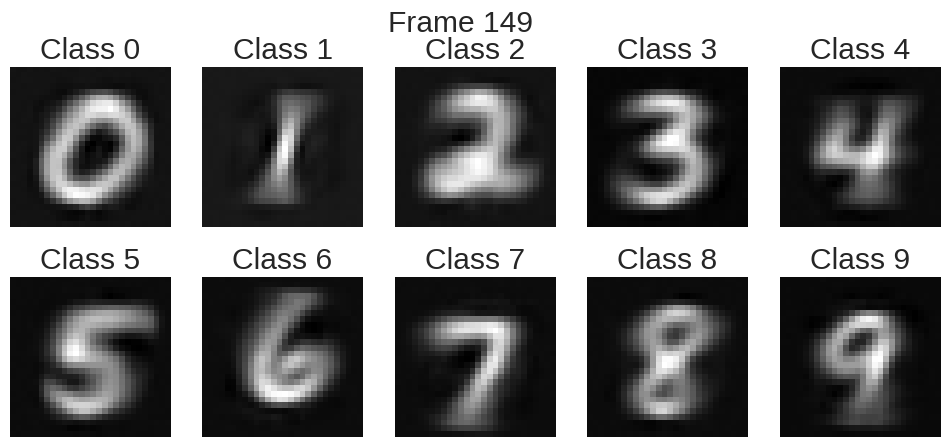

In [11]:
# Keep me
class_names = tf.range(10)
net.dream_input(class_names)

### 3e. Questions

**Question 4:** Describe what you see in the animation and interpret what it means (i.e. why do you see what you see in each figure panel in the order in which you see it).

**Answer 4:** The model predicts the input based on the given correct output, where each class index corresponds to a handwritten digit (0–9). During top-down training, it minimizes the error between the predicted input and the target output. As a result, each reconstructed image becomes progressively closer to its corresponding digit class (0–9).

### 3f. Filling in occluded parts of images

This subtask focuses on a neat application of the generative capabilities of PCNs — filling in or completing parts of test images that are *missing* (i.e. blanked out). 

#### (i) Visualizing occluded MNIST images

Run the cell below to generate versions of test set images in which the top half of pixels is blanked (**masked**) out.

*For the first few MNIST test set images, you should see the original image (top), occluded image (middle) and the occlusion mask used to generate the occluded image (bottom). In this plotting convention, parts of the mask that zero out corresponding parts of each image sample are black (0s) and parts that preserve the image data are white (1s).*

In [9]:
from image_datasets import occlude_images

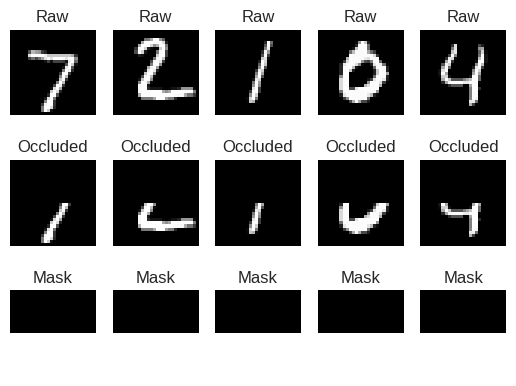

In [10]:
x_test_occ, masks = occlude_images(x_test, region='top')

items = [x_test, x_test_occ, masks]
labels = ['Raw', 'Occluded', 'Mask']

num_samples = 5
fig, axes = plt.subplots(3, num_samples)
for i in range(num_samples):
    for j in range(3):
        axes[j, i].imshow(tf.reshape(items[j][i], (28, 28)), cmap='gray')
        axes[j, i].set_title(labels[j], fontsize=12)
        axes[j, i].grid(False)
        axes[j, i].set_xticks([])
        axes[j, i].set_yticks([])

plt.show()

#### (ii) Add support for dreaming in masked parts of images

We will use your PCN's generative dreaming capability to "fill in" the occluded parts of the image based on the available information and the net's expectation for what should appear in the occluded image regions. For this to work, we need to slightly modify how your `InputPCNLayer` modifies its state: we ONLY want to have the net dream in MASKED parts of the image (non-occluded raw pixels should remain untouched as the state is updated).

In `InputPCNLayer` make the following small updates:
1. Implement `set_mask` to create an instance variable to store the masks for each test set mini-batch.
2. Modify `update_state` to use the occlusion mask to zero out the *top-down prediction error* in places where the input images were NOT MASKED by the occlusion mask (i.e. in places where there is actual useful image data). If there is no mask, modify the state like usual.

#### (iii) Finish method to fill in masked regions of image and animate the process

Follow the inline instructions to finish the implementation of the `complete_input` method in the `DensePCN` class, which will fill in the occluded parts of MNIST images.

Run the following code to animate the filling in process. *You should see a ~30 sec animation.*

**Note:** Replace `net` with your trained net's name.


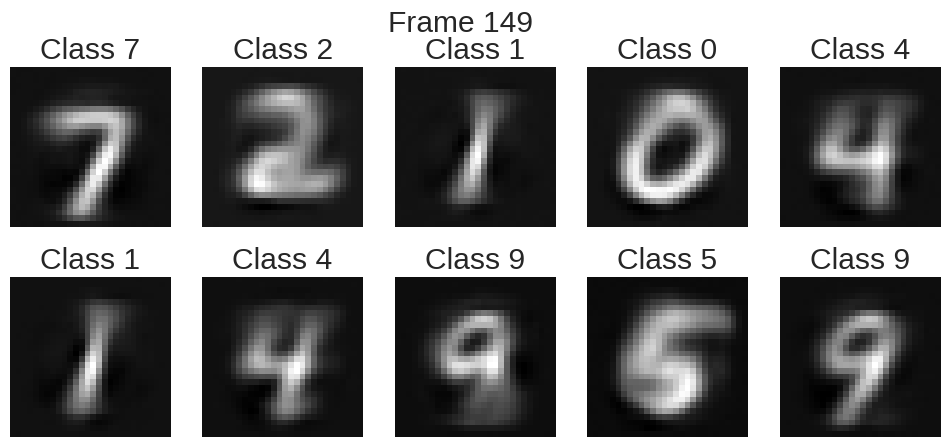

In [12]:
min_ind = 0
max_ind = 10
net.complete_input(x_test_occ[min_ind:max_ind],
                   masks[min_ind:max_ind],
                   y_test[min_ind:max_ind])

### 3g. Questions

**Question 5:**

(a) How closely do the filled in images resemble the original images?

(b) How sensible/plausible are the filled in content by the network?

**Answer 5:** Y

(a) Very close. All the number (predicted input) is recognizable.

(b) Since all the digits are recognizable, the reconstructions are generally sensible. However, some digits (such as 5 and 9) lose fine details in ways that are not typical of human handwriting. Therefore I think the fill-in are less plausible, since they do not fully resemble natural handwritten styles.

## Task 4: Dense PCN and CIFAR-10

This task focuses on evaluating the classification accuracy of your dense PCN on CIFAR-10. You will also visualize the expected images corresponding to each output neuron.

### 4a. Train and evaluate classification accuracy on CIFAR-10

In the cell below, train a Dense PCN with 1 hidden layer on *centered* preprocessed CIFAR-10 samples with the default train/val/test split.

Use default hyperparameters, except for the following:
- `10` epochs.
- Batch size of `256`.
- Learning rate of `1e-4`.

Print out the accuracy that you obtain on the test set. If everything is working as expected, you should be able to obtain **test accuracy ≥ 25%**.

In [13]:
tf.random.set_seed(42)
np.random.seed(42)

x_train_c, y_train_c, x_test_c, y_test_c = get_dataset('cifar10', norm_method='center')
x_train_c, y_train_c, x_val_c, y_val_c = train_val_split(x_train_c, y_train_c)

M_c = x_train_c.shape[1]
C_c = 10
num_epochs_c = 10
batch_size_c = 256
lr_c = 1e-4

net = DensePCN(input_feats_shape=(M_c,), C=C_c)
net.compile(loss='predictive', lr=lr_c, print_summary=True)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 39s 0us/step
x_train shape: (50000, 3072), dtype: <dtype: 'float32'>
y_train shape: (50000,), dtype: <dtype: 'int32'>
x_test shape: (10000, 3072), dtype: <dtype: 'float32'>
y_test shape: (10000,), dtype: <dtype: 'int32'>
---------------------------------------------------------------------------
OutputLayer (10 units). Output shape: None
PredLayer_0 (256 units). Output shape: None
InputLayer (3072 units). Output shape: None
---------------------------------------------------------------------------


In [14]:
N_c = len(x_train_c)
num_batches_c = N_c // batch_size_c
rng_c = np.random.default_rng(42)

for epoch in range(num_epochs_c):
    start_time = time.time()
    epoch_loss = 0.0

    for b in range(num_batches_c):
        indices = rng_c.integers(low=0, high=N_c, size=batch_size_c)
        x_batch = tf.gather(x_train_c, indices)
        y_batch = tf.gather(y_train_c, indices)
        net.set_layer_training_mode(True)
        net.update_states(net.train_num_steps, x_batch, y_batch)
        with tf.GradientTape() as tape:
            loss = net.loss()
        net.update_params(tape, loss)
        epoch_loss += float(loss)

    epoch_loss /= num_batches_c
    val_acc, val_loss = net.evaluate(x_val_c, y_val_c)
    elapsed = time.time() - start_time
    print(f'Epoch {epoch+1}/{num_epochs_c} | {elapsed:.1f}s | train_loss: {epoch_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}')

test_acc_c, test_loss_c = net.evaluate(x_test_c, y_test_c)
print(f'\nCIFAR-10 Test accuracy: {test_acc_c*100:.2f}%  |  Test loss: {test_loss_c:.4f}')

Epoch 1/10 | 16.9s | train_loss: 52.0388 | val_loss: 36.4614 | val_acc: 0.2454
Epoch 2/10 | 16.8s | train_loss: 30.6606 | val_loss: 69.5084 | val_acc: 0.2622
Epoch 3/10 | 16.8s | train_loss: 24.4435 | val_loss: 97.1256 | val_acc: 0.2758
Epoch 4/10 | 16.8s | train_loss: 21.0911 | val_loss: 90.3052 | val_acc: 0.2837
Epoch 5/10 | 16.6s | train_loss: 18.7567 | val_loss: 84.9827 | val_acc: 0.2804
Epoch 6/10 | 16.5s | train_loss: 17.0605 | val_loss: 78.2024 | val_acc: 0.2704
Epoch 7/10 | 16.5s | train_loss: 15.8171 | val_loss: 74.3352 | val_acc: 0.2718
Epoch 8/10 | 16.5s | train_loss: 14.7966 | val_loss: 72.0429 | val_acc: 0.2686
Epoch 9/10 | 16.7s | train_loss: 13.9856 | val_loss: 70.9699 | val_acc: 0.2648
Epoch 10/10 | 16.6s | train_loss: 13.3710 | val_loss: 71.6453 | val_acc: 0.2674

CIFAR-10 Test accuracy: 27.17%  |  Test loss: 72.3587


### 4b. Visualize expected inputs for each output neuron

Running the following code should show an animation of the expected input according to each output neuron of your trained PCN.

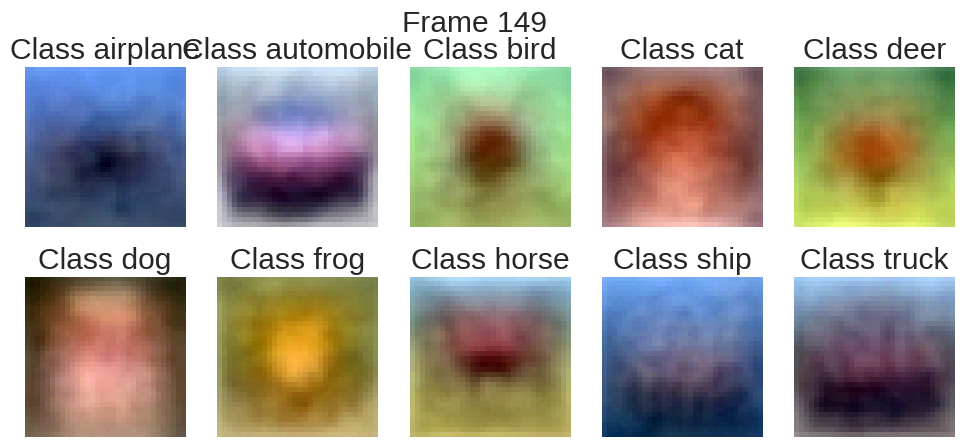

In [15]:
cifar_class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
net.dream_input(cifar_class_names, image_dims=(32, 32, 3))

### 4c. Questions

**Question 6:** Why are the expected inputs for each class blurrier than those that you generated for MNIST?

**Question 7:** Why might the blurriness of expected images of each class hinder the potential for feedback in the PCN to raise the classification accuracy?

**Answer 6:** Because in mnist dataset there's only black-and-white handwritten digits, where pixies are easily distinguishable. In cifar we have much more complex colorful images, making it harder to reconstruct input for the model.

**Answer 7:** The blurriness of the expected images indicates that they represent an average over many training examples. Because of this, the feedback signal provided by the PCN is less precise and contains less discriminative information. As a result, the network cannot effectively refine its predictions, since the feedback does not strongly favor one class over others. This reduces the potential for feedback to improve classification accuracy.